In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 2: Load the ISCX URL dataset
file_path = '/content/drive/MyDrive/major_project/All.csv'
df = pd.read_csv(file_path)

# Step 3: Identify columns
label_col = 'URL_Type_obf_Type'

# Step 4: Filter for Benign data
# The dataset contains pre-extracted features, not raw URLs
df_benign = df[df[label_col].astype(str).str.strip().str.lower() == 'benign'].copy()

# Drop the label to keep only features
X_benign = df_benign.drop(columns=[label_col])

# Convert to numeric, handle any errors (strings to NaN), and drop/fill NaNs
X_benign = X_benign.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Total benign samples isolated: {len(X_benign)}")
print(f"Feature count: {X_benign.shape[1]}")

# Step 5: Feature Scaling (Crucial for Autoencoders)
scaler = StandardScaler()
X_benign_scaled = scaler.fit_transform(X_benign)

# Step 6: Train-Test Split (80/20)
X_train, X_val = train_test_split(X_benign_scaled, test_size=0.2, random_state=42)

print(f"Training array shape: {X_train.shape}")
print(f"Validation array shape: {X_val.shape}")

# Step 7: Save the ML-ready data and the Scaler back to your Drive
save_dir = '/content/drive/MyDrive/major_project/'

np.save(save_dir + 'url_X_train_benign.npy', X_train)
np.save(save_dir + 'url_X_val_benign.npy', X_val)
joblib.dump(scaler, save_dir + 'url_scaler.pkl')

print("Preprocessing complete! Numeric features scaled and saved to Drive.")

Total benign samples isolated: 7781
Feature count: 79
Training array shape: (6224, 79)
Validation array shape: (1557, 79)
Preprocessing complete! Numeric features scaled and saved to Drive.


In [ ]:
print(df.head)

<bound method NDFrame.head of        Querylength  domain_token_count  path_token_count  avgdomaintokenlen  \
0                0                   4                 5           5.500000   
1                0                   4                 5           5.500000   
2                0                   4                 5           5.500000   
3                0                   4                12           5.500000   
4                0                   4                 6           5.500000   
...            ...                 ...               ...                ...   
36702           29                   4                14           5.750000   
36703            0                   4                13           3.750000   
36704           58                   3                27           6.666666   
36705           35                   3                13           4.333334   
36706           40                   3                25           6.666666   

       longdomaintoke

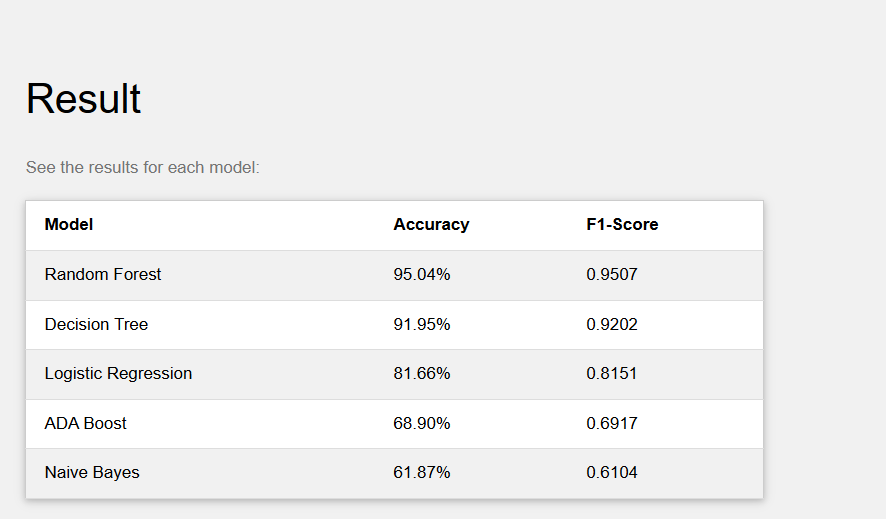

In [ ]:
# Install dependencies as needed:
# !pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the specific file name within the dataset
file_path = "malicious_phish.csv"

# Using the updated dataset_load function to avoid DeprecationWarning
df_kaggle = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sid321axn/malicious-urls-dataset",
  file_path
)

print("First 5 records:")
display(df_kaggle.head())

Using Colab cache for faster access to the 'malicious-urls-dataset' dataset.
First 5 records:


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [ ]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

print("Starting data preprocessing...")

# Step 1: Isolate the benign URLs based on the 'type' column
df_benign = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() == 'benign']
benign_urls = df_benign['url'].dropna().tolist()

print(f"Total benign URLs isolated for Autoencoder training: {len(benign_urls)}")

# Step 2: Define the custom URL tokenizer
# Standard NLP tokenizers look for spaces. This custom function forces the
# vectorizer to split the string at every special character (/, ., ?, =, etc.),
# which is essential for capturing malicious web patterns.
def url_tokenizer(url):
    return re.split(r'[^a-zA-Z0-9]', url)

# Step 3: Initialize TF-IDF Vectorizer
# The architecture explicitly dictates a 500-dimensional feature vector for Layer 2.
vectorizer = TfidfVectorizer(tokenizer=url_tokenizer, max_features=500)

print("Vectorizing URLs (this may take a couple of minutes depending on RAM)...")
# Fit the vectorizer only on the benign data and transform it into a numerical array
X_benign_vectorized = vectorizer.fit_transform(benign_urls).toarray()

print(f"Vectorization complete! Array shape: {X_benign_vectorized.shape}")

Starting data preprocessing...
Total benign URLs isolated for Autoencoder training: 428103
Vectorizing URLs (this may take a couple of minutes depending on RAM)...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vectorization complete! Array shape: (428103, 500)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import joblib
from google.colab import drive
import os

# Step 4: Create the 80/20 train-test split for the Stage 1 Autoencoder
X_train, X_val = train_test_split(X_benign_vectorized, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

# Step 5: Mount Google Drive to save the processed files securely
drive.mount('/content/drive')

# Define your save directory
save_dir = '/content/drive/MyDrive/major_project/'

# Ensure the directory exists, if not, create it
os.makedirs(save_dir, exist_ok=True)

# Step 6: Export the data
np.save(save_dir + 'url_X_train_benign.npy', X_train)
np.save(save_dir + 'url_X_val_benign.npy', X_val)
joblib.dump(vectorizer, save_dir + 'url_tfidf_vectorizer.pkl')

print("Success! ML-ready arrays and the TF-IDF vectorizer have been saved to your Drive.")

Training set shape: (342482, 500)
Validation set shape: (85621, 500)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! ML-ready arrays and the TF-IDF vectorizer have been saved to your Drive.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import json
import os

print(f"TensorFlow Version: {tf.__version__}")

# Step 1: Load the prepared datasets from Google Drive
save_dir = '/content/drive/MyDrive/major_project/'

print("Loading training and validation arrays...")
X_train = np.load(save_dir + 'url_X_train_benign.npy')
X_val = np.load(save_dir + 'url_X_val_benign.npy')

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

# Step 2: Define the Autoencoder Architecture
# Input Layer (500 dimensions from TF-IDF)
input_dim = X_train.shape[1]
input_layer = layers.Input(shape=(input_dim,))

# Encoder (Compressing down to the bottleneck)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dense(64, activation='relu')(encoded)

# Bottleneck Layer (Exactly 32 dimensions as per Layer 3 design)
bottleneck = layers.Dense(32, activation='relu', name='bottleneck')(encoded)

# Decoder (Reconstructing back to 500 dimensions)
decoded = layers.Dense(64, activation='relu')(bottleneck)
decoded = layers.Dense(128, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Build and compile the model
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

print("\n--- Model Architecture ---")
autoencoder.summary()

# Step 3: Train the Autoencoder
# We use X_train for both input and target because the goal is reconstruction
print("\nStarting training phase...")
history = autoencoder.fit(
    X_train, X_train,
    epochs=25,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True,
    verbose=1
)

# Step 4: Calculate the Anomaly Threshold
# The threshold is Mean + 2 * Standard Deviations of the reconstruction error on normal data
print("\nCalculating the anomaly threshold on the validation set...")
reconstructions = autoencoder.predict(X_val)

# Calculate Mean Squared Error for each sample
mse = np.mean(np.power(X_val - reconstructions, 2), axis=1)

threshold_mean = np.mean(mse)
threshold_std = np.std(mse)
anomaly_threshold = threshold_mean + (2 * threshold_std)

print(f"Validation MSE Mean: {threshold_mean:.6f}")
print(f"Validation MSE Std Dev: {threshold_std:.6f}")
print(f"DYNAMIC ANOMALY THRESHOLD SET AT: {anomaly_threshold:.6f}")

# Step 5: Save the Model and the Threshold
autoencoder.save(save_dir + 'url_autoencoder.h5')

threshold_data = {'url_anomaly_threshold': float(anomaly_threshold)}
with open(save_dir + 'url_threshold.json', 'w') as f:
    json.dump(threshold_data, f)

print("\nSuccess! The Autoencoder model (.h5) and threshold (.json) have been saved to your Drive.")

TensorFlow Version: 2.20.0
Loading training and validation arrays...
X_train shape: (342482, 500)
X_val shape: (85621, 500)

--- Model Architecture ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │        64,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,396 (583.58 KB)

 Trainable params: 149,396 (583.58 KB)

 Non-trainable params: 0 (0.00 B)


Starting training phase...
Epoch 1/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 0.0058 - val_loss: 0.0017
Epoch 2/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 3/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 4/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 5/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 6/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0011 - val_loss: 9.1799e-04
Epoch 8/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 8.1707e-04 - val_loss: 7.3862e-04
Epoch 9/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 6.6902e-04 - val_loss: 6.1233e-04
Epoch 10/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5.6459e-04 - val_loss: 5.2667e-04
Epoch 11/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 

Validation MSE Mean: 0.000231
Validation MSE Std Dev: 0.000385
DYNAMIC ANOMALY THRESHOLD SET AT: 0.001001

Success! The Autoencoder model (.h5) and threshold (.json) have been saved to your Drive.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import json
import re

print("Loading saved assets from Google Drive...")
save_dir = '/content/drive/MyDrive/major_project/'

# 1. Load the trained Autoencoder
autoencoder = load_model(save_dir + 'url_autoencoder.h5', compile=False)

# 2. Load the trained TF-IDF Vectorizer
vectorizer = joblib.load(save_dir + 'url_tfidf_vectorizer.pkl')

# 3. Load the dynamic Anomaly Threshold
with open(save_dir + 'url_threshold.json', 'r') as f:
    threshold_data = json.load(f)
anomaly_threshold = threshold_data['url_anomaly_threshold']

print(f"Assets loaded successfully. Active Threshold: {anomaly_threshold:.6f}\n")

# 4. Grab a mix of malicious URLs from your original Kaggle dataframe
# (Assuming df_kaggle is still in your Colab memory from the previous steps)
df_malicious = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() != 'benign'].copy()

# Take 5 random malicious URLs for the test
sample_test_urls = df_malicious.sample(5, random_state=42)['url'].tolist()
sample_labels = df_malicious.sample(5, random_state=42)['type'].tolist()

print("--- TESTING UNSEEN MALICIOUS URLs ---")
for url, label in zip(sample_test_urls, sample_labels):
    print(f"URL: {url} \n(True Label: {label})")

# 5. Preprocess the unseen URLs using the EXACT SAME tokenizer and vectorizer
X_test_malicious = vectorizer.transform(sample_test_urls).toarray()

# 6. Feed the malicious URLs through the Autoencoder
reconstructions = autoencoder.predict(X_test_malicious)

# 7. Calculate the Mean Squared Error (MSE) for each
mse_scores = np.mean(np.power(X_test_malicious - reconstructions, 2), axis=1)

print("\n--- INFERENCE RESULTS ---")
for i in range(len(sample_test_urls)):
    score = mse_scores[i]
    is_anomaly = score > anomaly_threshold

    print(f"URL {i+1} Anomaly Score: {score:.6f}")

    if is_anomaly:
        print(">>> RESULT: ANOMALY DETECTED (Threshold Breached)")
        print(">>> ACTION: Flagged and routed to Layer 4 (DistilBERT) for CWE Classification\n")
    else:
        print(">>> RESULT: NORMAL (Threshold Not Breached)")
        print(">>> ACTION: Discarded as benign\n")

Loading saved assets from Google Drive...
Assets loaded successfully. Active Threshold: 0.000616

--- TESTING UNSEEN MALICIOUS URLs ---
URL: http://mzracing.sk/index.php?page=shop.product_details&category_id=165&flypage=flypage.tpl&product_id=992&option=com_virtuemart&Itemid=14 
(True Label: defacement)
URL: http://www.kloster-hornbach.de/de/tagen-und-feiern/romantiker/rahmenprogramme 
(True Label: defacement)
URL: www.boardgame.de/reviews/voldampf.htm 
(True Label: phishing)
URL: http://www.africanapostolicmissionchurch.org/ax.docc/ 
(True Label: phishing)
URL: www.w3.org/TR/NOTE-sgml-xml 
(True Label: phishing)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step

--- INFERENCE RESULTS ---
URL 1 Anomaly Score: 0.000742
>>> RESULT: ANOMALY DETECTED (Threshold Breached)
>>> ACTION: Flagged and routed to Layer 4 (DistilBERT) for CWE Classification

URL 2 Anomaly Score: 0.000074
>>> RESULT: NORMAL (Threshold Not Breached)
>>> ACTION: Discarded as benign

URL 3 Anomaly Score: 0.000448
>>> RESULT: NORMA

In [ ]:
import pandas as pd
import numpy as np
import json

# Step 1: Adjust threshold for higher sensitivity (Mean + 1*Std instead of 2)
new_threshold = threshold_mean + (1 * threshold_std)
anomaly_threshold = new_threshold

# Save the updated threshold
with open(save_dir + 'url_threshold.json', 'w') as f:
    json.dump({'url_anomaly_threshold': float(anomaly_threshold)}, f)

def predict_url(input_url, actual_label="Unknown"):
    X_input = vectorizer.transform([input_url]).toarray()
    reconstruction = autoencoder.predict(X_input, verbose=0)
    mse_score = np.mean(np.power(X_input - reconstruction, 2))
    is_anomaly = mse_score > anomaly_threshold

    print(f"URL: {input_url[:70]}...")
    print(f"Actual: {actual_label} | Score: {mse_score:.6f} | Threshold: {anomaly_threshold:.6f}")

    if is_anomaly:
        print(">>> RESULT: ANOMALY DETECTED (Routing to Layer 4)")
    else:
        print(">>> RESULT: BENIGN (Pass through)")
    print("-" * 30)

print(f"Updated Threshold to: {anomaly_threshold:.6f} (Increased Sensitivity)\n")

# Re-run validation against the same malicious samples
sample_malicious = df_kaggle[df_kaggle['type'] != 'benign'].sample(5, random_state=42)
for _, row in sample_malicious.iterrows():
    predict_url(row['url'], row['type'])

print("Testing manually crafted suspicious URL:")
predict_url("http://secure-login-update.verification-service.com/a1b2c3d4e5f6g7h8i9j0/update.php?cmd=exec", "Crafted Malicious")

Updated Threshold to: 0.000616 (Increased Sensitivity)

URL: http://mzracing.sk/index.php?page=shop.product_details&category_id=165...
Actual: defacement | Score: 0.000742 | Threshold: 0.000616
>>> RESULT: ANOMALY DETECTED (Routing to Layer 4)
------------------------------
URL: http://www.kloster-hornbach.de/de/tagen-und-feiern/romantiker/rahmenpr...
Actual: defacement | Score: 0.000074 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
URL: www.boardgame.de/reviews/voldampf.htm...
Actual: phishing | Score: 0.000448 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
URL: http://www.africanapostolicmissionchurch.org/ax.docc/...
Actual: phishing | Score: 0.000034 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
URL: www.w3.org/TR/NOTE-sgml-xml...
Actual: phishing | Score: 0.000003 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
Testing manu

Loading assets to evaluate thresholds...
Calculating baseline metrics from validation set...
Creating a mixed test set (10,000 Benign / 10,000 Malicious)...
Vectorizing test URLs and running inference...

--- EVALUATING THRESHOLDS ---


,Multiplier (σ),Threshold (MSE),Recall / Sensitivity,False Positive Rate,F1-Score
0,0.50,0.0004,0.3813,0.2145,0.4779
1,1.00,0.0006,0.3064,0.1572,0.4187
2,1.25,0.0007,0.2617,0.1321,0.3755
3,1.50,0.0008,0.2131,0.1078,0.3227
4,1.75,0.0009,0.1671,0.0872,0.2664
5,2.00,0.0010,0.1276,0.0673,0.2136
6,2.50,0.0012,0.0682,0.0360,0.1235
7,3.00,0.0014,0.0296,0.0202,0.0564


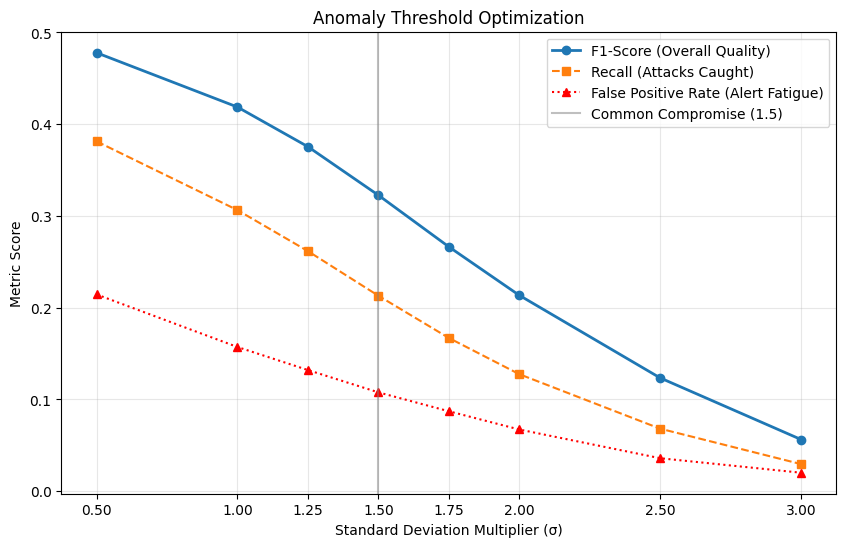

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from tensorflow.keras.models import load_model
import joblib

print("Loading assets to evaluate thresholds...")
save_dir = '/content/drive/MyDrive/major_project/'

# 1. Load the model, vectorizer, and the benign validation set
X_val = np.load(save_dir + 'url_X_val_benign.npy')
autoencoder = load_model(save_dir + 'url_autoencoder.h5', compile=False)
vectorizer = joblib.load(save_dir + 'url_tfidf_vectorizer.pkl')

# 2. Calculate the exact baseline mean and standard deviation from benign data
print("Calculating baseline metrics from validation set...")
val_reconstructions = autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)
baseline_mean = np.mean(val_mse)
baseline_std = np.std(val_mse)

# 3. Create a balanced, mixed test set from df_kaggle
print("Creating a mixed test set (10,000 Benign / 10,000 Malicious)...")
df_benign_test = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() == 'benign'].sample(10000, random_state=42)
df_malicious_test = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() != 'benign'].sample(10000, random_state=42)

df_test = pd.concat([df_benign_test, df_malicious_test])

# Define True Labels: 0 for Benign (Normal), 1 for Malicious (Anomaly)
y_true = np.where(df_test['type'].astype(str).str.strip().str.lower() == 'benign', 0, 1)
test_urls = df_test['url'].tolist()

# 4. Vectorize and get MSE scores for the test set
print("Vectorizing test URLs and running inference...")
X_test = vectorizer.transform(test_urls).toarray()
test_reconstructions = autoencoder.predict(X_test, verbose=0)
test_mse = np.mean(np.power(X_test - test_reconstructions, 2), axis=1)

# 5. Sweep through different Multipliers
multipliers = [0.5, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
results = []

print("\n--- EVALUATING THRESHOLDS ---")
for m in multipliers:
    threshold = baseline_mean + (m * baseline_std)

    # 1 if MSE > threshold (Flagged as Anomaly), else 0 (Passed as Benign)
    y_pred = (test_mse > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        'Multiplier (σ)': m,
        'Threshold (MSE)': threshold,
        'Recall / Sensitivity': recall,
        'False Positive Rate': fpr,
        'F1-Score': f1
    })

# 6. Display Data Table
results_df = pd.DataFrame(results)
display(results_df.round(4))

# 7. Plot the Trade-offs
plt.figure(figsize=(10, 6))
plt.plot(results_df['Multiplier (σ)'], results_df['F1-Score'], marker='o', linewidth=2, label='F1-Score (Overall Quality)')
plt.plot(results_df['Multiplier (σ)'], results_df['Recall / Sensitivity'], marker='s', linestyle='--', label='Recall (Attacks Caught)')
plt.plot(results_df['Multiplier (σ)'], results_df['False Positive Rate'], marker='^', linestyle=':', color='red', label='False Positive Rate (Alert Fatigue)')

plt.title("Anomaly Threshold Optimization")
plt.xlabel("Standard Deviation Multiplier (σ)")
plt.ylabel("Metric Score")
plt.xticks(multipliers)
plt.axvline(x=1.5, color='gray', alpha=0.5, linestyle='-', label='Common Compromise (1.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()